# Proyek Analisis Data: Bike Sharing Analysis
- **Nama:** Raja Samudra Tandepadang
- **Email:** raja.t.padang@gmail.com
- **ID Dicoding:** rajasmdra

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Pada musim apa penyewaan sepeda mencapai jumlah tertinggi?
- **Pertanyaan 2:** Bagaimana kondisi cuaca dapat memengaruhi jumlah penyewaan sepeda?
- **Pertanyaan 3:** Bagaimana perbedaan jumlah penyewaan sepeda pada hari weekday dan weekend?
- **Pertanyaan 4:** Bagaimana pengaruh parameter cuaca terhadap jumlah penyewaan sepeda?
- **Pertanyaan 5:** Bagaimana perbedaan perilaku pengguna casual dan registered ketika menyewa sepeda?

## Import Semua Packages/Library yang Digunakan

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load day df

In [232]:
day_df = pd.read_csv('data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load hour df

In [233]:
hour_df = pd.read_csv('data/hour.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Load dataset day.csv (Data peminjaman sepeda per hari)
- Load dataset hour.csv (Data peminjaman sepeda per jam)

### Assessing Data

#### Identifying missing value problem

In [234]:
print("day df missing value")
day_df.isnull().sum()

day df missing value


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [235]:
print("hour df missing value")
hour_df.isnull().sum()

hour df missing value


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

#### Identifying duplicates problem

In [236]:
print("day df duplicates:", day_df.duplicated().sum())
print("hour df duplicates:", hour_df.duplicated().sum())

day df duplicates: 0
hour df duplicates: 0


#### Identifying data type problem

In [237]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [238]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Identifying data distribution problem

In [239]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [240]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ada missing values dan duplicated data pada kedua dataset
- Permasalahan pada data tanggal:
    - Kolom dteday masih bertipe string
    - kolom year masih dalam bentuk normalisasi
    - kolom month dan day masih dalam bentuk string
- Beberapa kolum kategori seperti season dan weathersit masih bertipe integer
- Beberapa kolom numerik seperti temp, atemp, hum, dan windspeed masih dalam bentuk normalisasi
- Tidak ada keanehan dalam ringkasan parameter statistik dari kedua dataset

**Steps to Take:**
- Memperbaiki format pada data tanggal agar sesuai
- Mengubah tipe data kolom kategori menjadi string
- Mengubah nilai beberapa kolom numerik menjadi nilai asli

### Cleaning Data

#### Fixing date data problem

In [241]:
years = {0: 2011, 1: 2012}

months = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 
    5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 
    10: 'October', 11: 'November', 12: 'December',
}

days = {
    0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 
    4: 'Thursday', 5: 'Friday', 6: 'Saturday'
}

day_df['yr'] = day_df['yr'].map(years)
day_df['mnth'] = day_df['mnth'].map(months)
day_df['weekday'] = day_df['weekday'].map(days)
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

hour_df['yr'] = hour_df['yr'].map(years)
hour_df['mnth'] = hour_df['mnth'].map(months)
hour_df['weekday'] = hour_df['weekday'].map(days)
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

#### Fixing categorical column problem

In [242]:
seasons = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weathersits = {
    1: 'Clear, Partly cloudy',
	2: 'Mist, Cloudy',
	3: 'Light Snow, Light Rain',
	4: 'Heavy Rain, Snow'
}

day_df['season'] = day_df['season'].map(seasons)
day_df['weathersit'] = day_df['weathersit'].map(weathersits)

hour_df['weathersit'] = hour_df['weathersit'].map(weathersits)
hour_df['season'] = hour_df['season'].map(seasons)

#### Fixing numerical column problem

In [243]:
day_df['temp'] = day_df['temp'] * 41
day_df['atemp'] = day_df['atemp'] * 50
day_df['hum'] = day_df['hum'] * 100
day_df['windspeed'] = day_df['windspeed'] * 67

hour_df['temp'] = hour_df['temp'] * 41
hour_df['atemp'] = hour_df['atemp'] * 50
hour_df['hum'] = hour_df['hum'] * 100
hour_df['windspeed'] = hour_df['windspeed'] * 67

In [244]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,Saturday,0,"Mist, Cloudy",14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,2011-01-02,Spring,2011,January,0,Sunday,0,"Mist, Cloudy",14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,2011-01-03,Spring,2011,January,0,Monday,1,"Clear, Partly cloudy",8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,2011-01-04,Spring,2011,January,0,Tuesday,1,"Clear, Partly cloudy",8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,2011-01-05,Spring,2011,January,0,Wednesday,1,"Clear, Partly cloudy",9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [245]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,0,Saturday,0,"Clear, Partly cloudy",9.84,14.395,81.0,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,0,Saturday,0,"Clear, Partly cloudy",9.02,13.635,80.0,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,0,Saturday,0,"Clear, Partly cloudy",9.02,13.635,80.0,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,0,Saturday,0,"Clear, Partly cloudy",9.84,14.395,75.0,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,0,Saturday,0,"Clear, Partly cloudy",9.84,14.395,75.0,0.0,0,1,1


In [246]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [247]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  object        
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Format pada data tanggal sudah diperbaiki dan sesuai
- Kolom kategori sudah diubah menjadi string
- Kolom numerik sudah dikembalikan ke nilai aslinya

## Exploratory Data Analysis (EDA)

### Explore heatmap

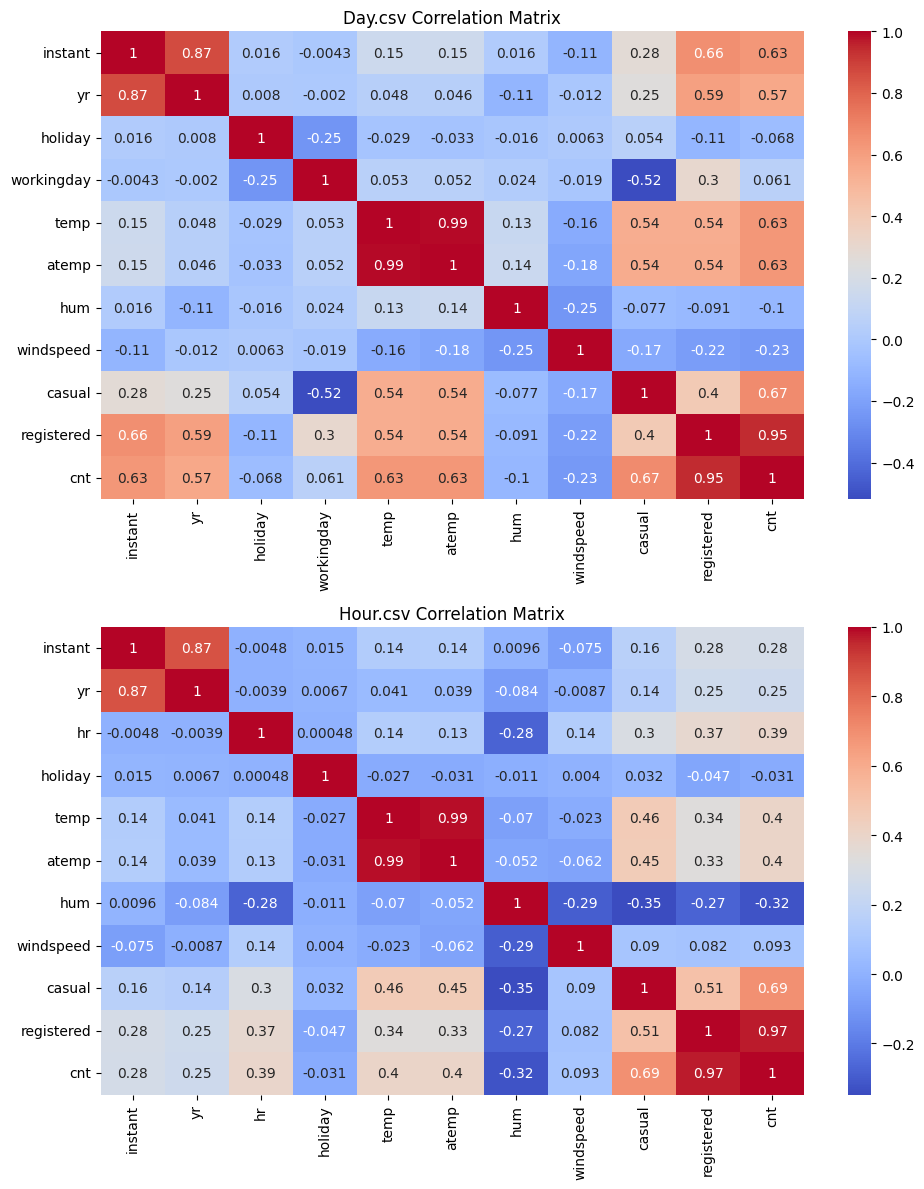

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

numerical_cols_day = day_df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_cols_day.corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Day.csv Correlation Matrix')

numerical_cols_hour = hour_df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_cols_hour.corr(), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Hour.csv Correlation Matrix')

plt.tight_layout()
plt.show()

**Insight:** 
- Grafik ini bertujuan untuk menunjukkan kekuatan dan arah hubungan (korelasi) antara variabel cuaca, waktu, dan karakteristik pengguna terhadap total sepeda yang disewa.
- Warna merah pada grafik artinya terdapat hubungan positif (semakin tinggi nilai variabel tersebut, semakin meningkat jumlah penyewaan), sedangkan warna biru artinya hubungan negatif (semakin tinggi nilai variabel tersebut, semakin menurun jumlah penyewaan).
- Terdapat perbedaan korelasi antara data day dan hour sehingga membutuhkan analisis lebih lanjut. Sebagai contoh, variabel kelembapan (hum) memiliki dampak negatif yang jauh lebih sensitif dan instan pada skala per jam daripada skala harian. Sebaliknya, pengaruh suhu (temp) terlihat jauh lebih dominan dalam menentukan total akumulasi penyewaan secara harian dibandingkan fluktuasi per jamnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada musim apa penyewaan sepeda mencapai jumlah tertinggi?

In [248]:
rent_by_season_df = day_df.groupby(by='season').cnt.mean().sort_values(ascending=False).reset_index()
rent_by_season_df

,season,cnt
0,Fall,5644.303191
1,Summer,4992.331522
2,Winter,4728.162921
3,Spring,2604.132597


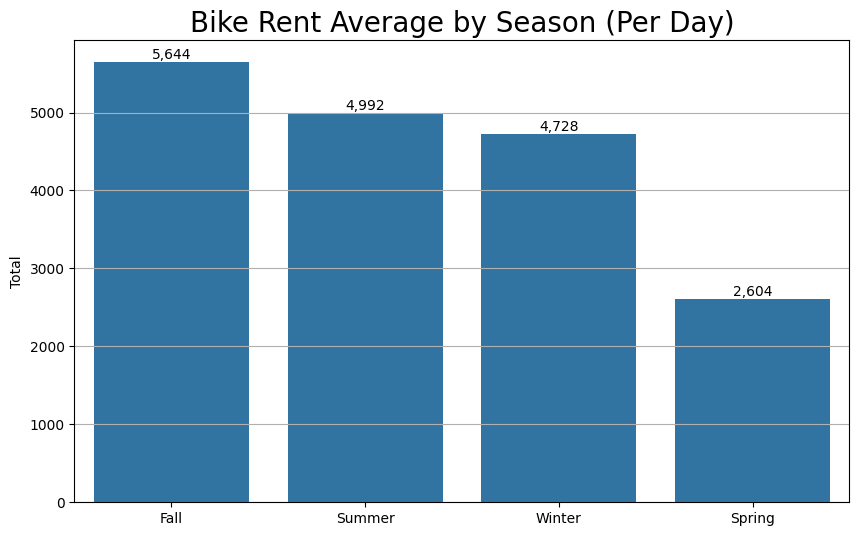

In [249]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='season',
    y='cnt',
    data=rent_by_season_df
)
plt.xlabel(None)
plt.ylabel('Total')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Bike Rent Average by Season (Per Day)', loc='center', fontsize=20)
plt.grid(axis='y')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:,.0f}')
plt.show()

**Insight:**
- Jumlah penyewaan sepeda tertinggi berada di musim gugur dengan rata-rata 236 sepeda/hari
- Musim semi memiliki jumlah penyewaan sepeda paling rendah dengan rata-rata 111 sepeda/hari

### Pertanyaan 2: Bagaimana kondisi cuaca dapat memengaruhi jumlah penyewaan sepeda?

In [250]:
rent_by_weather_df = day_df.groupby(by='weathersit').cnt.mean().sort_values(ascending=False).reset_index()
rent_by_weather_df

,weathersit,cnt
0,"Clear, Partly cloudy",4876.786177
1,"Mist, Cloudy",4035.862348
2,"Light Snow, Light Rain",1803.285714


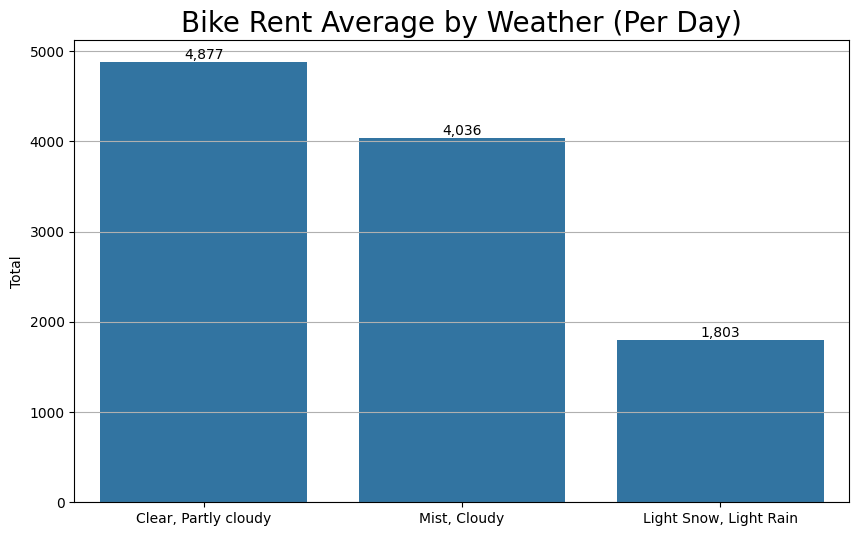

In [251]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='weathersit',
    y='cnt',
    data=rent_by_weather_df
)
plt.xlabel(None)
plt.ylabel('Total')
plt.title("Bike Rent Average by Weather (Per Day)", loc='center', fontsize=20)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y')
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x:,.0f}')
plt.show()

**Insight:**
- Jumlah penyewaan sepeda mencatatkan rata-rata tertinggi ketika cuaca sedang cerah dan sebagian berawan
- Ketika cuaca sedang hujan deras dan salju, rata-rata jumlah penyewaan sepeda berada di paling rendah

### Pertanyaan 3: Bagaimana perbedaan jumlah penyewaan sepeda pada hari weekday dan weekend?

In [252]:
hour_df['workingday'] = hour_df['workingday'].apply(lambda x: "Weekday" if x == 1 else "Weekend")

In [253]:
rent_by_hour = hour_df.groupby(by=['workingday', 'hr']).cnt.mean().reset_index()
rent_by_hour

,workingday,hr,cnt
0,Weekday,0,36.786290
1,Weekday,1,16.552632
2,Weekday,2,8.683778
3,Weekday,3,4.942553
4,Weekday,4,5.429787
5,Weekday,5,24.913131
6,Weekday,6,102.500000
7,Weekday,7,290.612903
8,Weekday,8,477.006048
9,Weekday,9,241.518145


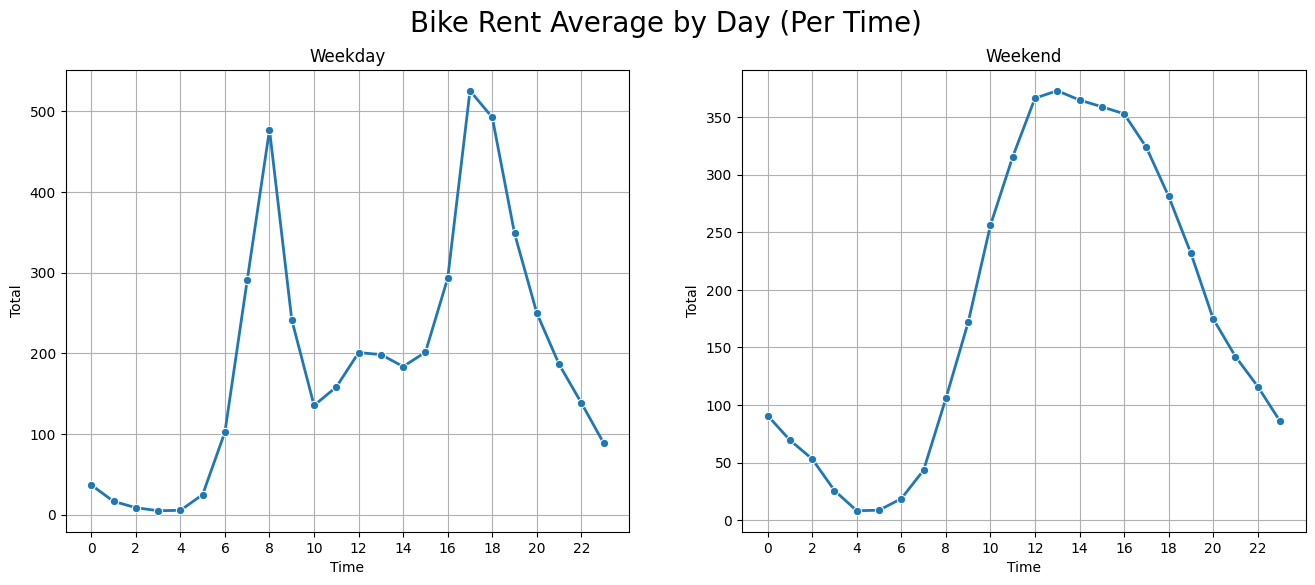

In [254]:
days = {'Weekday', 'Weekend'}

plt.figure(figsize=(16, 6))
for i, day in enumerate(days):
    plt.subplot(1, 2, i + 1)
    sns.lineplot(
        x='hr',
        y='cnt',
        data=rent_by_hour[rent_by_hour['workingday'] == day],
        marker='o',
        linewidth=2
    )
    plt.xlabel('Time')
    plt.ylabel('Total')
    plt.title(day)
    plt.xticks(np.arange(0, 24, step=2))
    plt.grid()


plt.suptitle("Bike Rent Average by Day (Per Time)", fontsize=20)
plt.tight_layout
plt.show()

**Insight:**
- Pada hari weekday, jumlah pengguna sepeda meningkat pada pukul 08:00 dan 17:00 (Jam Sibuk). Sedangkan pada hari weekend jumlah pengguna sepeda mengalami puncaknya di antara pukull 12:00-16:00. 
- Hal ini menunjukkan bahwa pada hari weekday, pengguna menggunakan sepeda untuk pergi bekerja/sekolah yang ditunjukkan dengan peningkatan jumlah ketika jam sibuk. Sedangkan ketika weekend, pengguna lebih sering menggunakan sepeda untuk rekreasi dan beolahraga.

### Pertanyaan 4: Bagaimana pengaruh parameter cuaca terhadap jumlah penyewaan sepeda?

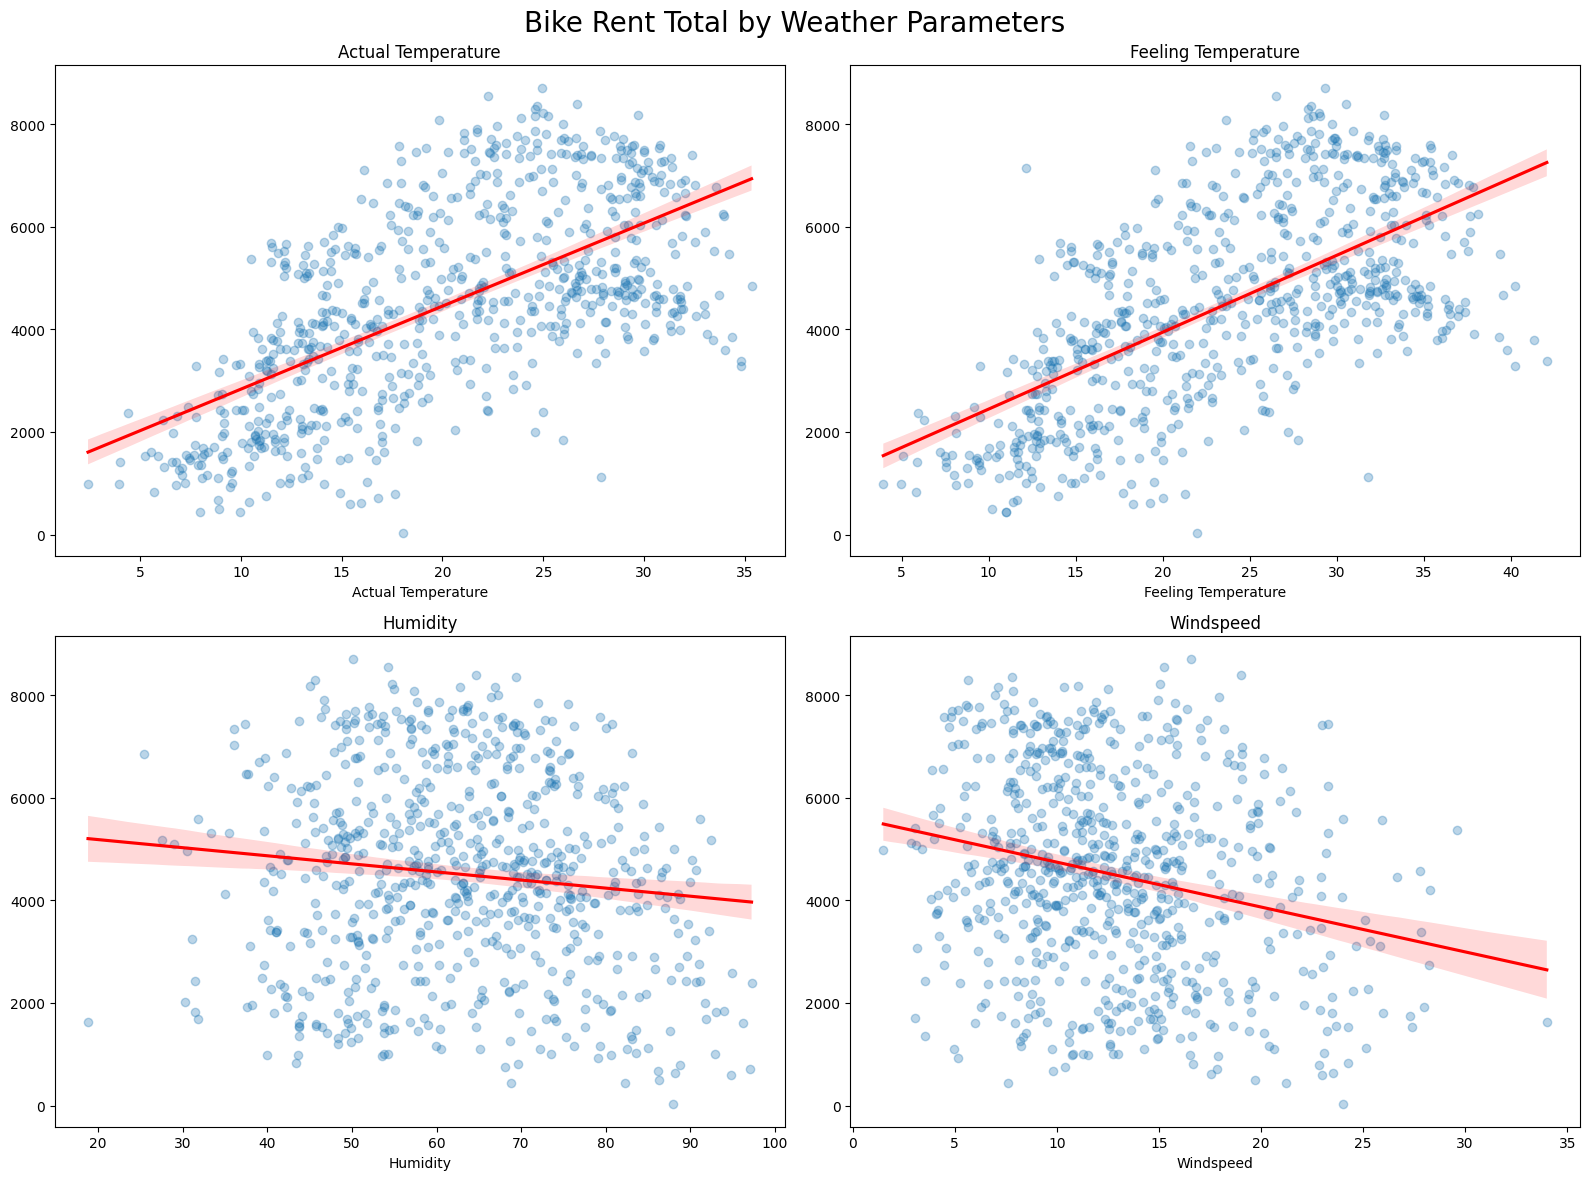

In [255]:
weather_params = {
    'temp': 'Actual Temperature', 
    'atemp': 'Feeling Temperature', 
    'hum': 'Humidity', 
    'windspeed': 'Windspeed'
}

plt.figure(figsize=(16, 12))
for i, (params, label) in enumerate(weather_params.items()):
    plt.subplot(2, 2, i + 1)
    sns.regplot(x=params, y='cnt', data=day_df[day_df[params] != 0], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title(f'{label}')
    plt.xlabel(label)
    plt.ylabel(None)

plt.suptitle("Bike Rent Total by Weather Parameters", fontsize=20)
plt.tight_layout()
plt.show()

**Insight:**
- Jumlah penyewaan sepeda meningkat ketika suhu berada di kisaran 20-30°C (Hangat) dan ketika suhu tubuh berada di 30-35°C. Perbedaan suhu ini disebabkan oleh beberapa faktor seperti kelembapan udara dan kecepatan angin
- Kelembapan udara yang nyaman untuk bersepeda berada di 40-50%. Kelembapan yang terlalu rendah menyebabkan pengguna kehilangan banyak cairan tubuh ketika bersepeda sehingga menyebabkan dehidrasi. Sedangkan jika terlalu tinggi menyebabkan keringat di tubuh sulit untuk menguap, sehingga tubuh terasa lebih gerah/panas
- Pengguna merasa nyaman bersepeda ketika kecepatan angin berada di 10-20 km/jam, angin sepoi-sepoi membantu mendinginkan tubuh saat bersepeda. Ketika kecepatan angin berada di atas 20 km/jam jumlah penyewaan sepeda mulai menurun karena angin yang kencang menyebabkan bersepeda terasa lebih berat karena hambatan udara (aerodinamis) dan faktor keselamatan

### Pertanyaan 5: Bagaimana perbedaan perilaku pengguna casual dan registered ketika menyewa sepeda?

In [256]:
rent_by_day = day_df.groupby(by='workingday').cnt.mean().reset_index()
rent_by_day

,workingday,cnt
0,0,4330.168831
1,1,4584.820000


In [257]:
rent_by_user = day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()
rent_by_user

,workingday,casual,registered
0,0,1371.134199,2959.034632
1,1,606.570000,3978.250000


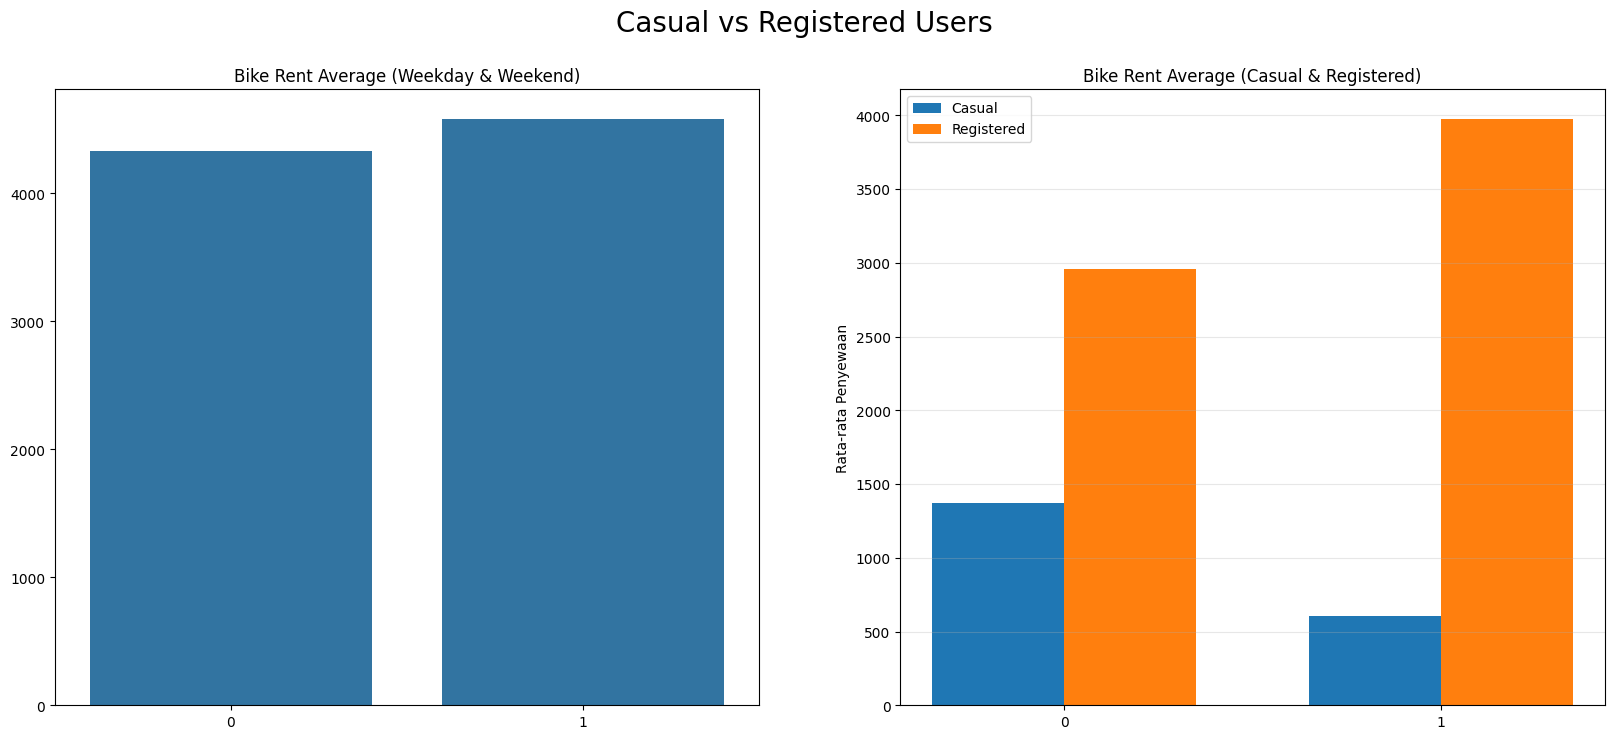

In [258]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

sns.barplot(x='workingday', y='cnt', data=rent_by_day, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title('Bike Rent Average (Weekday & Weekend)')

x = range(len(rent_by_user))
width = 0.35
ax[1].bar([i - width/2 for i in x], rent_by_user['casual'], width, label='Casual')
ax[1].bar([i + width/2 for i in x], rent_by_user['registered'], width, label='Registered')
ax[1].set_title('Bike Rent Average (Casual & Registered)')
ax[1].set_ylabel('Rata-rata Penyewaan')
ax[1].set_xticks(x)
ax[1].set_xticklabels(rent_by_user.workingday)
ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)

plt.suptitle("Casual vs Registered Users", fontsize=20)
plt.show()

**Insight:**
- Jumlah pengguna casual pada akhir pekan meningkat dibandingkan pada hari kerja, sedangkan jumlah pengguna registered mengalami penurunan ketika akhir pekan jika dibandingkan dengan hari kerja.
- Sebagian user registered mendaftar karena mereka menggunakannya untuk aktivitas seharian terutama pada hari kerja, sedangkan user casual kebanyakan hanya mengggunakan sepeda ketika pergi berlibur atau berolahraga di akhir pekan

## Analisis Lanjutan (Opsional)

### Segmentasi Permintaan Berdasarkan Musim dan Cuaca

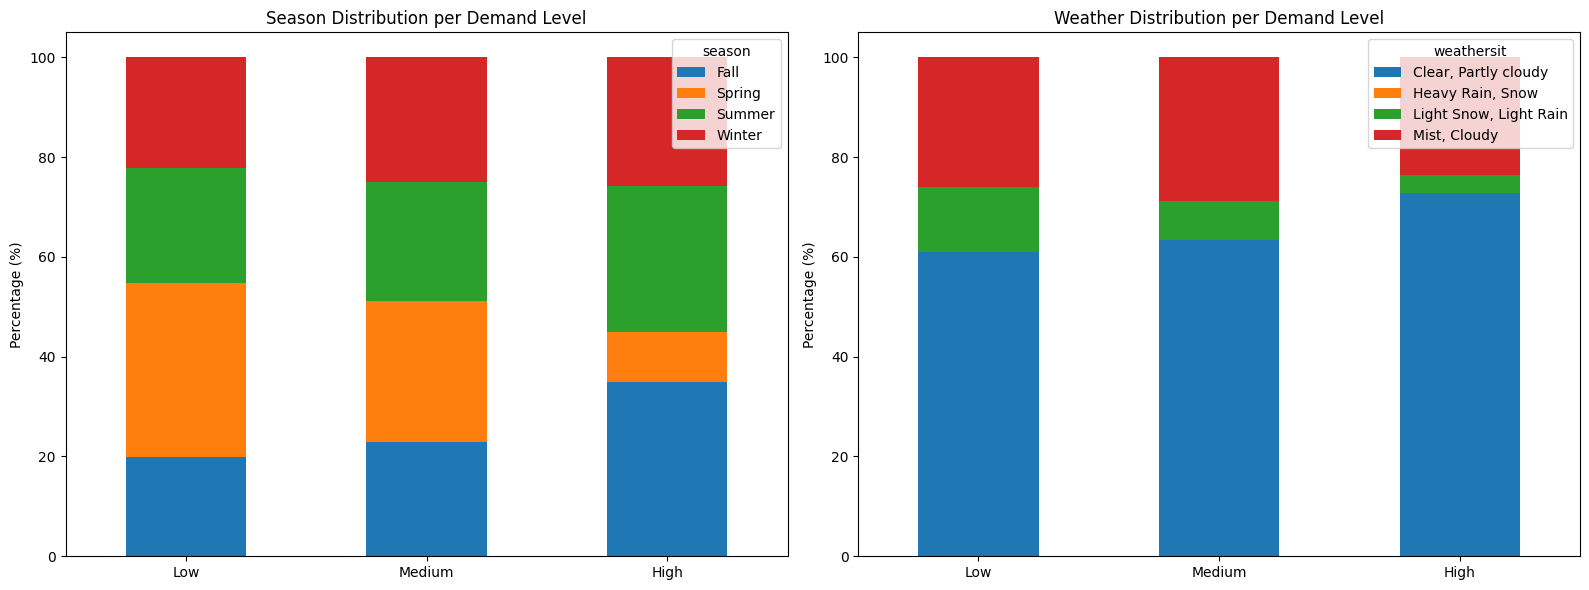

In [262]:
q1 = hour_df['cnt'].quantile(0.33)
q2 = hour_df['cnt'].quantile(0.67)

hour_df['demand'] = pd.cut(
    hour_df['cnt'], 
    bins=[0, q1, q2, hour_df['cnt'].max()],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

params = {'season': 'Season', 'weathersit': 'Weather'}

plt.figure(figsize=(16, 6))
for i, (param, label) in enumerate(params.items()):
    ax = plt.subplot(1, 2, i + 1)
    demand = pd.crosstab(hour_df['demand'], hour_df[param], normalize='index') * 100
    demand.plot(kind='bar', stacked=True, ax=ax)
    plt.title(f'{label} Distribution per Demand Level')
    plt.xlabel(None)
    plt.ylabel('Percentage (%)')
    plt.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Insight:**
- Musim Gugur (Fall) menjadi penggerak utama terciptanya permintaan tinggi (High Demand), sementara Musim Semi (Spring) justru mendominasi tingkat permintaan rendah (Low Demand) akibat suhu transisi yang masih dingin dan kondisi jalanan yang sering basah/becek.
- Distribusi Cuaca (Weather Distribution per Demand Level)
Tingkat permintaan tinggi (High Demand) dipimpin mutlak oleh kondisi Cuaca Cerah (Clear/Partly Cloudy), sedangkan kondisi Cuaca HUjan Berat atau Salju (Heavy Rain/Snow) secara signifikan menekan minat pengguna dan menjatuhkan performa bisnis ke level rendah hingga sedang.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Siklus bisnis bike sharing sangat dipengaruhi oleh perubahan musim, di mana Musim Gugur (Fall) merupakan periode emas (peak season) dengan performa tertinggi akibat suhu yang ideal, sedangkan Musim Semi (Spring) menjadi titik terendah bisnis (low season) karena kendala suhu transisi yang dingin dan infrastruktur jalan yang basah/becek.
- **Conclusion pertanyaan 2:** Kondisi Cuaca Cerah (Clear/Partly Cloudy) adalah pemicu mutlak (key driver) untuk mencapai target penjualan tertinggi (High Demand). Sebaliknya, cuaca buruk seperti Mendung, Hujan Lebat, atau Salju secara signifikan melumpuhkan minat bersepeda, sehingga performa bisnis anjlok ke level paling rendah.
- **Conclusion pertanyaan 2:** Terdapat dikotomi fungsi penggunaan sepeda yang jelas antara hari kerja dan hari libur. Pada Hari Kerja (Weekday), sepeda berfungsi sebagai transportasi komuter kaku (fokus pada jam masuk/pulang kantor pukul 08:00 dan 17:00). Sementara pada Akhir Pekan (Weekend), fungsi bergeser total menjadi moda rekreasi fleksibel dengan aktivitas puncak di siang hari (12:00–16:00).
- **Conclusion pertanyaan 2:** Tingkat penyewaan sepeda mencapai titik optimal hanya ketika berada pada Zonasi Nyaman (Comfort Zone) termal manusia, yaitu: suhu udara hangat (20-30°C), kelembapan moderat (40-50%), dan kecepatan angin sepoi-sepoi (10-20 km/jam). Penyimpangan ekstrem dari parameter ini (terlalu dingin, dehidrasi, gerah, atau hambatan angin kencang) otomatis menurunkan volume penyewaan.
- **Conclusion pertanyaan 2:** Basis pengguna Registered adalah penggerak roda bisnis utama di hari kerja karena menggunakannya untuk utilitas harian (bekerja/sekolah). Sebaliknya, pengguna Casual adalah pasar potensial musiman yang sangat bergantung pada momentum hari libur untuk aktivitas rekreasi dan olahraga.

### **Rekomendasi Action Item:**

### 1. Manajemen Armada dan Operasional

* **Optimalisasi Musim Gugur:** Lakukan pemeliharaan menyeluruh sebelum musim gugur agar seluruh unit siap beroperasi guna menyerap volume permintaan tertinggi.
* **Efisiensi Musim Semi:** Jadwalkan perawatan besar dan pergudangan sebagian armada pada musim semi untuk menekan biaya operasional saat permintaan sepi.
* **Fasilitas Tambahan:** Lengkapi sepeda dengan penahan cipratan air (spakbor) untuk mengantisipasi jalur yang basah akibat pencairan salju di musim semi.

### 2. Distribusi Armada Berbasis Waktu

* **Logistik Hari Kerja:** Pastikan ketersediaan unit di area perumahan sebelum pukul 08:00, lalu geser distribusi ke area perkantoran menjelang pukul 17:00.
* **Logistik Akhir Pekan:** Alihkan konsentrasi armada dari kawasan bisnis ke pusat wisata, taman, dan area olahraga sebelum pukul 12:00 hingga 16:00.

### 3. Strategi Pemasaran dan Segmentasi

* **Retensi Pengguna Terdaftar:** Tawarkan program loyalitas atau paket khusus korporasi/kampus untuk menjaga konsistensi transaksi pada hari kerja.
* **Aktivasi Pengguna Kasual:** Sediakan paket khusus akhir pekan yang diintegrasikan dengan rute wisata kota untuk menarik minat pesepeda rekreasi.

### 4. Promosi Berbasis Kondisi Cuaca

* **Notifikasi Kontekstual:** Kirimkan promosi otomatis melalui aplikasi saat indikator cuaca menunjukkan kondisi cerah dan suhu berada di zona nyaman.
* **Insentif Cuaca Redup:** Berikan potongan harga atau poin ekstra pada hari mendung untuk merangsang permintaan dan menjaga stabilitas transaksi.